# Capstone Phase 3B — Improving on the Base Paper
## DA-HGNN: a Disagreement-Aware Heterogeneous Graph Neural Network for emotion recognition in social media

**M A Kaushik · CH.SC.U4CSE24123 · PSID 181** · Base paper: Maazallahi, Asadpour & Bazmi (2025), IP&M 62, 103974
Prerequisite: `Capstone_Phase3A_Paper_Replication.ipynb` (it produces the cached LM scores in `data/processed/`).

### What the replication (3A) taught us
1. The paper's best HGNN results depend on the random seed (0.344 ± 0.228 accuracy on disagreed posts).
2. Disagreed posts are a different population: mostly *neutral* on GoEmotions and Friends. TEC has no neutral class at all.
3. A model trained only to imitate the two LMs cannot know more than they do. Our prototypes confirmed this: label-free students tie with simply averaging the two LMs.

### What DA-HGNN changes
| | Base paper | DA-HGNN (ours) |
|---|---|---|
| Tweet features | 7 DistilRoBERTa scores | both LMs' scores + **disagreement descriptors** (confidence, entropy, Jensen–Shannon divergence) + both LMs' **sentence embeddings** |
| Phrase features | mean/std of agreed tweets (zero vector if none) | same + **contextual phrase embedding** (no phrase is left empty) |
| Graph | tweet–phrase–emotion | + **tweet–tweet semantic k-NN** relation (semantic attention now chooses between two relations at tweet nodes) |
| Training signal | hard agreed label | **confidence-weighted soft labels** from both LMs (knowledge distillation) + **score-masking noise**, plus **a small gold set** (semi-supervised) |
| Label space | always 7 classes | **aligned to the dataset's taxonomy** (no neutral on TEC) |
| Decision | GNN output | **fusion** with a **disagreement-calibrated** LM teacher smoothed over the graph |
| Protocol | best of a grid, chosen by similarity to RoBERTa | fixed design chosen on dev data; untouched 80% test split; 5 seeds; ablations; significance tests |

### Two settings
* **Setting A — label-free** (the paper's setting): no human labels at all.
* **Setting B — few labels** (our main setting): a small gold set of **N = 500 posts per dataset** (1.6–4.3% of the data). All baselines get the same N labels.

In [1]:
import os, sys, re, json, html, random, time, itertools, warnings, subprocess
from collections import Counter, defaultdict

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torch_geometric'], check=True)
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/Capstone Project'   # change if the folder is elsewhere in Drive
else:
    PROJECT_DIR = os.getcwd()

PROC_DIR = os.path.join(PROJECT_DIR, 'data', 'processed')
REP_DIR = os.path.join(PROJECT_DIR, 'results', 'replication')
RES_DIR = os.path.join(PROJECT_DIR, 'results', 'improved')
RUN_DIR = os.path.join(RES_DIR, 'runs')            # cached predictions of every trained model (lets re-runs resume)
for d in (RES_DIR, RUN_DIR):
    os.makedirs(d, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import scipy.sparse as sp
from scipy import stats
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import scatter
from transformers import AutoTokenizer, AutoModel
from transformers.utils import logging as hf_logging
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Project dir:', PROJECT_DIR)
print('Device     :', DEVICE, torch.cuda.get_device_name(0) if DEVICE == 'cuda' else '')

C:\Users\kaush\venvs\capstone\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Project dir: C:\Users\kaush\OneDrive\ドキュメント\College\ML\Capstone Project
Device     : cuda NVIDIA GeForce RTX 2060


### Configuration
The design and hyperparameters were fixed in prototyping on the dev portion of each dataset. The 80% test portion was never used for any decision.

In [2]:
CFG = dict(
    lms={'distil': 'j-hartmann/emotion-english-distilroberta-base', 'roberta': 'j-hartmann/emotion-english-roberta-large'},
    labels=['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise'],
    datasets=['GoEmotions', 'Friends', 'TEC'],
    pool_frac=0.2, split_seed=42,            # 20% labelled pool (dev) / 80% untouched test
    n_labels=500,                            # Setting B label budget per dataset
    top_k_phrases=4, textrank_window=3, edge_mean=0.5, edge_std=0.1,   # paper's phrase rules
    knn_k=10,                                # semantic tweet-tweet neighbours
    hidden=256, layers=2, dropout=0.3, attn_size=64,
    lr=2e-3, weight_decay=1e-4, epochs=200, patience=25,
    mask_p=0.3,                              # score-masking (disagreement simulation) rate
    fusion_w=0.5,                            # weight of DA-HGNN vs calibrated teacher in the final decision
    smooth_alpha=0.5, smooth_iters=10,
    seeds=[0, 1, 2, 3, 4], ablation_seeds=[0, 1, 2],
    budgets=[50, 100, 200, 500, 1000, 2000], budget_seeds=[0, 1, 2],
)
LABELS = CFG['labels']; L2I = {l: i for i, l in enumerate(LABELS)}; N_CLS = len(LABELS); NEU = L2I['neutral']
COLS = {m: [f'{m}_{l}' for l in LABELS] for m in ('distil', 'roberta', 'distil_v2')}

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

## 1. Data
Phase 3A's cleaned datasets and LM scores are reused, so the data is identical to the replication. Each dataset is split once (stratified by gold label) into a **20% pool**, from which the N gold labels are drawn, and an **80% test** portion used only for the final numbers.

In [3]:
DATA = {}
for n in CFG['datasets']:
    p = os.path.join(PROC_DIR, f'{n.lower()}_scored.csv')
    if not os.path.exists(p):
        raise FileNotFoundError(f'{p} not found — run Capstone_Phase3A_Paper_Replication.ipynb first.')
    d = pd.read_csv(p, keep_default_na=False)
    pool, _ = train_test_split(np.arange(len(d)), train_size=CFG['pool_frac'], random_state=CFG['split_seed'], stratify=d['gold'])
    d['split'] = 'test'; d.loc[pool, 'split'] = 'pool'
    DATA[n] = d
summary = pd.DataFrame({n: {'posts': len(d), 'pool (labelled candidates)': (d.split == 'pool').sum(), 'test (80%)': (d.split == 'test').sum(),
                            'classes in taxonomy': d.gold.nunique(), f'N = {CFG["n_labels"]} labels = % of data': round(100 * CFG['n_labels'] / len(d), 1)}
                        for n, d in DATA.items()}).T
summary

,posts,pool (labelled candidates),test (80%),classes in taxonomy,N = 500 labels = % of data
GoEmotions,31621.0,6324.0,25297.0,7.0,1.6
Friends,11731.0,2346.0,9385.0,7.0,4.3
TEC,21051.0,4210.0,16841.0,6.0,2.4


## 2. Multi-view node features (C1)
* **LM scores:** DistilRoBERTa ⊕ RoBERTa-large (14-d). The paper uses DistilRoBERTa only.
* **Disagreement descriptors:** the confidence (max probability) of each LM, the entropy of their average, and the Jensen–Shannon divergence between them (4-d). These describe *how* the two models disagree.
* **Sentence embeddings:** mean-pooled last hidden layer of both LMs (768 + 1024-d, z-scored). These come from the same two models the paper uses, so no new data source is added. They are cached in `data/processed/*_emb_*.npy`.

In [4]:
def embed(model_name, texts, bs=64):
    tok = AutoTokenizer.from_pretrained(model_name)
    m = AutoModel.from_pretrained(model_name).to(DEVICE).eval()
    if DEVICE == 'cuda': m = m.half()
    idx = np.argsort([len(t) for t in texts]); out = np.zeros((len(texts), m.config.hidden_size), np.float16)
    with torch.inference_mode():
        for s in range(0, len(texts), bs):
            b = idx[s:s + bs]
            enc = tok([texts[i] for i in b], padding=True, truncation=True, max_length=128, return_tensors='pt').to(DEVICE)
            h = m(**enc).last_hidden_state.float(); msk = enc['attention_mask'].unsqueeze(-1).float()
            out[b] = ((h * msk).sum(1) / msk.sum(1)).cpu().numpy().astype(np.float16)
    del m
    if DEVICE == 'cuda': torch.cuda.empty_cache()
    return out

def js_div(A, B):
    M = (A + B) / 2
    kl = lambda P, Q: (P * (np.log(P + 1e-9) - np.log(Q + 1e-9))).sum(1)
    return 0.5 * kl(A, M) + 0.5 * kl(B, M)

FEAT = {}
for n, d in DATA.items():
    E = []
    for k, hf in CFG['lms'].items():
        f = os.path.join(PROC_DIR, f'{n.lower()}_emb_{k}.npy')
        if not os.path.exists(f):
            print(f'{n}: embedding with {hf} ...'); np.save(f, embed(hf, d['clean'].tolist()))
        E.append(np.load(f).astype(np.float32))
    E = np.hstack(E); E = (E - E.mean(0)) / (E.std(0) + 1e-6)
    A = d[COLS['distil']].values.astype(np.float32); B = d[COLS['roberta']].values.astype(np.float32); M = (A + B) / 2
    desc = np.stack([A.max(1), B.max(1), -(M * np.log(M + 1e-9)).sum(1) / np.log(N_CLS), js_div(A, B)], 1).astype(np.float32)
    FEAT[n] = dict(A=A, B=B, M=M, V2=d[COLS['distil_v2']].values.astype(np.float32), desc=desc, E=E.astype(np.float32),
                   la=A.argmax(1), lb=B.argmax(1), comp=A.argmax(1) == B.argmax(1), gold=d['gold'].map(L2I).values,
                   test=(d['split'] == 'test').values, pool=np.where(d['split'] == 'pool')[0],
                   allowed=np.array([l in set(d['gold']) for l in LABELS]))
    print(f'{n:10s} embeddings {E.shape}  agreed {FEAT[n]["comp"].mean():.1%}  classes allowed: {[l for l, a in zip(LABELS, FEAT[n]["allowed"]) if a]}')

GoEmotions embeddings (31621, 1792)  agreed 72.7%  classes allowed: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']


Friends    embeddings (11731, 1792)  agreed 72.1%  classes allowed: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']


TEC        embeddings (21051, 1792)  agreed 67.1%  classes allowed: ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']


## 3. Heterogeneous graph (C1, C4)
* **Phrase nodes:** TextRank key phrases, using the same procedure as the paper and 3A. Features are the mean ⊕ std of the agreed tweets' LM scores (28-d), a flag for "has at least one agreed tweet", and a **contextual phrase embedding**: the mean embedding of all tweets containing the phrase.
* **Phrase → emotion edges:** the paper's rule (mean > 0.5, std < 0.1), applied to the average of the two LMs.
* **Tweet → tweet edges (new):** the 10 nearest neighbours by cosine similarity of the sentence embeddings.

In [5]:
STOP = set(ENGLISH_STOP_WORDS) | {"i'm", "it's", "that's", "you're", "i've", "i'll", "he's", "she's", "they're", "we're",
                                  "there's", "what's", "let's", "i'd", "you'll", "you've", "we've", "they've", 'im', 'dont', 'thats', 'youre'}
TOKEN_RE = re.compile(r"[a-z][a-z']+")

def textrank_phrases(text, top_k=CFG['top_k_phrases'], window=CFG['textrank_window']):
    words = [w.strip("'") for w in TOKEN_RE.findall(text.lower())]
    cands = [w for w in words if w not in STOP and len(w) > 2]
    if not cands:
        return []
    g = nx.Graph(); g.add_nodes_from(cands)
    for i in range(len(cands)):
        for j in range(i + 1, min(i + window, len(cands))):
            if cands[i] != cands[j]:
                g.add_edge(cands[i], cands[j])
    rank = nx.pagerank(g) if g.number_of_edges() else {w: 1.0 for w in g}
    top = set(sorted(rank, key=rank.get, reverse=True)[:top_k])
    phrases, run = set(top), []
    for i, w in enumerate(words):
        if w in top and (not run or i == run[-1][0] + 1):
            run.append((i, w))
        else:
            if len(run) > 1: phrases.add(' '.join(x for _, x in run))
            run = [(i, w)] if w in top else []
    if len(run) > 1: phrases.add(' '.join(x for _, x in run))
    return sorted(phrases)

def knn_edges(E, k):
    X = F.normalize(torch.tensor(E, device=DEVICE), dim=1); src, dst = [], []
    for s in range(0, len(X), 4096):
        sim = X[s:s + 4096] @ X.T
        sim[torch.arange(sim.shape[0]), torch.arange(s, s + sim.shape[0])] = -1
        src.append(sim.topk(k, dim=1).indices.reshape(-1))
        dst.append(torch.arange(s, s + sim.shape[0], device=DEVICE).repeat_interleave(k))
    return torch.stack([torch.cat(src), torch.cat(dst)])            # neighbour -> tweet

GRAPH = {}
for n, d in DATA.items():
    f = FEAT[n]
    phrases = d['clean'].map(textrank_phrases)
    vocab = sorted({p for ps in phrases for p in ps}); p2i = {p: i for i, p in enumerate(vocab)}
    tp = np.array([(t, p2i[p]) for t, ps in enumerate(phrases) for p in ps]).T
    Mx = sp.csr_matrix((np.ones(tp.shape[1], np.float32), (tp[0], tp[1])), shape=(len(d), len(vocab)))
    Mc = sp.diags(f['comp'].astype(np.float32)) @ Mx
    sup = np.asarray(Mc.sum(0)).ravel(); den = np.maximum(sup, 1)[:, None]
    S = np.hstack([f['A'], f['B']])
    mean = np.asarray(Mc.T @ S) / den; std = np.sqrt(np.clip(np.asarray(Mc.T @ S ** 2) / den - mean ** 2, 0, None))
    cnt = np.maximum(np.asarray(Mx.sum(0)).ravel(), 1)[:, None]
    xp = np.hstack([mean, std, (sup > 0)[:, None], np.asarray(Mx.T @ f['E']) / cnt]).astype(np.float32)
    m7 = np.asarray(Mc.T @ f['M']) / den; s7 = np.sqrt(np.clip(np.asarray(Mc.T @ f['M'] ** 2) / den - m7 ** 2, 0, None))
    pe = (m7 > CFG['edge_mean']) & (s7 < CFG['edge_std']) & (sup[:, None] > 0)
    pe_idx = np.array(np.nonzero(pe))
    t = lambda a: torch.tensor(np.ascontiguousarray(a), dtype=torch.long, device=DEVICE)
    ei = {('tweet', 'has', 'phrase'): t(tp), ('phrase', 'in', 'tweet'): t(tp[::-1]),
          ('phrase', 'signals', 'emotion'): t(pe_idx), ('emotion', 'signalled_by', 'phrase'): t(pe_idx[::-1]),
          ('tweet', 'similar', 'tweet'): knn_edges(f['E'], CFG['knn_k'])}
    GRAPH[n] = dict(phrases=phrases, vocab=vocab, Mx=Mx, pe=pe, ei=ei, xp=torch.tensor(xp, device=DEVICE), xe=torch.eye(N_CLS, device=DEVICE))
    print(f'{n:10s} tweets={len(d):6,d} phrases={len(vocab):6,d} T-P={tp.shape[1]:7,d} P-E={pe_idx.shape[1]:6,d} T-T(kNN)={ei[("tweet","similar","tweet")].shape[1]:7,d} '
          f'phrases without agreed tweet={int((sup == 0).sum()):,} (now have embedding features)')

GoEmotions tweets=31,621 phrases=38,746 T-P=132,152 P-E=22,394 T-T(kNN)=316,210 phrases without agreed tweet=8,736 (now have embedding features)


Friends    tweets=11,731 phrases= 9,439 T-P= 33,292 P-E= 5,155 T-T(kNN)=117,310 phrases without agreed tweet=2,204 (now have embedding features)


TEC        tweets=21,051 phrases=32,838 T-P=102,969 P-E=17,111 T-T(kNN)=210,510 phrases without agreed tweet=9,361 (now have embedding features)


## 4. DA-HGNN model and training objective (C2, C3)
**Layer:** the paper's Eq. 1 (GraphSAGE-style per relation), $h_u[m] = W[m]\,[W_U h_u \,\|\, W_T\,\text{mean}_{t\in N_m(u)} h_t]$, followed by **semantic attention** across relations (Eq. 4–5). Tweet nodes now receive two relations (phrase→tweet, tweet→tweet), so attention has a real choice to make. We add input projections per node type, residual connections with LayerNorm, and a skip connection from the tweet's own features.

**Objective (semi-supervised):**
$\mathcal{L} = \underbrace{\frac{\sum_{i\in\text{agreed}} w_i\,\mathrm{KL}(q_i \,\|\, p_\theta(x_i))}{\sum w_i}}_{\text{label-free distillation from both LMs}} + \underbrace{\frac{1}{|L|}\sum_{j\in L} \mathrm{CE}(y_j, p_\theta(x_j))}_{\text{N gold labels}}$

Here $q_i \propto p_\text{distil}\odot p_\text{roberta}$ (product of experts) and $w_i=\sqrt{\max p_\text{distil}\cdot\max p_\text{roberta}}$. **Score masking:** during training, the LM-score block of 30% of agreed tweets is hidden, which simulates disagreement and forces the model to use the text and graph. Early stopping uses 20% of the gold set (semi-supervised) or 10% of agreed tweets (label-free). Logits for classes outside the dataset's taxonomy are masked (C6).

In [6]:
class HeteroGNNConv(nn.Module):                       # paper Eq. (1)-(2)
    def __init__(self, in_src, in_dst, out):
        super().__init__()
        self.lin_dst, self.lin_src, self.lin_update = nn.Linear(in_dst, out), nn.Linear(in_src, out), nn.Linear(2 * out, out)
    def forward(self, x_src, x_dst, ei):
        agg = scatter(x_src[ei[0]], ei[1], dim=0, dim_size=x_dst.size(0), reduce='mean')
        return self.lin_update(torch.cat([self.lin_dst(x_dst), self.lin_src(agg)], dim=-1))

class HeteroLayer(nn.Module):                          # paper Eq. (4)-(5): semantic attention over relations
    def __init__(self, dims, out, edge_types, attn_size):
        super().__init__()
        self.edge_types = edge_types
        self.convs = nn.ModuleDict({'__'.join(et): HeteroGNNConv(dims[et[0]], dims[et[2]], out) for et in edge_types})
        self.attn = nn.ModuleDict({t: nn.Sequential(nn.Linear(out, attn_size), nn.Tanh(), nn.Linear(attn_size, 1, bias=False))
                                   for t in {et[2] for et in edge_types}})
        self.alpha = {}
    def forward(self, x, ei):
        msgs, names = defaultdict(list), defaultdict(list)
        for et in self.edge_types:
            msgs[et[2]].append(self.convs['__'.join(et)](x[et[0]], x[et[2]], ei[et])); names[et[2]].append(f'{et[0]}→{et[2]}')
        out = {}
        for t, hs in msgs.items():
            H = torch.stack(hs, 1)
            if len(hs) > 1:
                a = torch.softmax(self.attn[t](H).mean(0), 0); self.alpha[t] = (names[t], a.detach().view(-1))
                out[t] = (a.unsqueeze(0) * H).sum(1)
            else:
                out[t] = H[:, 0]
        return out

class DAHGNN(nn.Module):
    def __init__(self, d_tweet, d_phrase, edge_types, hidden=CFG['hidden'], layers=CFG['layers'], dropout=CFG['dropout']):
        super().__init__()
        self.proj = nn.ModuleDict({'tweet': nn.Linear(d_tweet, hidden), 'phrase': nn.Linear(d_phrase, hidden), 'emotion': nn.Linear(N_CLS, hidden)})
        self.layers = nn.ModuleList([HeteroLayer({k: hidden for k in self.proj}, hidden, edge_types, CFG['attn_size']) for _ in range(layers)])
        self.norms = nn.ModuleList([nn.ModuleDict({k: nn.LayerNorm(hidden) for k in self.proj}) for _ in range(layers)])
        self.skip, self.cls, self.dropout = nn.Linear(d_tweet, hidden), nn.Linear(2 * hidden, N_CLS), dropout
    def forward(self, x_tweet, g):
        x = {'tweet': self.proj['tweet'](x_tweet), 'phrase': self.proj['phrase'](g['xp']), 'emotion': self.proj['emotion'](g['xe'])}
        x = {k: F.dropout(F.relu(v), self.dropout, self.training) for k, v in x.items()}
        for layer, norm in zip(self.layers, self.norms):
            h = layer(x, g['ei'])
            x = {k: F.dropout(F.relu(norm[k](h.get(k, torch.zeros_like(v)) + v)), self.dropout, self.training) for k, v in x.items()}
        return self.cls(torch.cat([x['tweet'], F.relu(self.skip(x_tweet))], -1))

class MLP(nn.Module):                                  # same features, no graph (ablation / baseline)
    def __init__(self, d_in, hidden=CFG['hidden'], dropout=CFG['dropout']):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_in, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Dropout(dropout), nn.Linear(hidden, N_CLS))
    def forward(self, x, g=None): return self.net(x)


def tweet_input(f, score_mask=None, use_scores=True, use_emb=True, paper_feats=False):
    if paper_feats:                                    # the paper's tweet features: DistilRoBERTa scores only
        return torch.tensor(f['A'], device=DEVICE)
    parts = []
    if use_scores:
        S = np.hstack([f['A'], f['B'], f['desc']])
        m = np.zeros((len(S), 1), np.float32) if score_mask is None else score_mask[:, None].astype(np.float32)
        parts += [S * (1 - m), m]
    if use_emb:
        parts.append(f['E'])
    return torch.tensor(np.hstack(parts), dtype=torch.float32, device=DEVICE)

def run_cached(key, fn):
    path = os.path.join(RUN_DIR, re.sub(r'[^A-Za-z0-9_.=-]+', '_', key) + '.npy')
    if os.path.exists(path):
        return np.load(path).astype(np.float32)
    out = fn(); np.save(path, out.astype(np.float16)); return out

def train_model(n, lab=(), seed=0, graph=True, kd=True, soft=True, weighted=True, mask_p=CFG['mask_p'],
                use_emb=True, use_scores=True, knn=True, phrases=True, paper_feats=False):
    # returns log-probabilities for every tweet; lab = indices of gold-labelled posts (empty -> label-free)
    f, G = FEAT[n], GRAPH[n]
    set_seed(seed); rng = np.random.RandomState(seed)
    ei = {k: v for k, v in G['ei'].items() if (knn or k[1] != 'similar') and (phrases or k[1] == 'similar')}
    g = dict(G, ei=ei)
    q = f['A'] * f['B']; q[:, ~f['allowed']] = 0; q = q / q.sum(1, keepdims=True)   # product of experts over the taxonomy
    if not soft: q = np.eye(N_CLS, dtype=np.float32)[q.argmax(1)]
    w = np.sqrt(f['A'].max(1) * f['B'].max(1)) if weighted else np.ones(len(q), np.float32)
    q, w = torch.tensor(q, device=DEVICE), torch.tensor(w, dtype=torch.float32, device=DEVICE)
    y = torch.tensor(f['gold'], device=DEVICE); disallowed = torch.tensor(~f['allowed'], device=DEVICE)
    kd_idx = np.where(f['comp'])[0]
    lab = np.array(lab, dtype=int); rng.shuffle(lab)
    if len(lab):
        n_va = max(10, len(lab) // 5); va_l, tr_l = lab[:n_va], lab[n_va:]
        kd_tr = kd_idx
    else:
        kd_tr, kd_va = train_test_split(kd_idx, test_size=0.1, random_state=seed, stratify=f['la'][kd_idx])
    x0 = tweet_input(f, use_scores=use_scores, use_emb=use_emb, paper_feats=paper_feats)
    model = (DAHGNN(x0.shape[1], g['xp'].shape[1], list(ei.keys())) if graph else MLP(x0.shape[1])).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    T = lambda a: torch.tensor(a, device=DEVICE)
    best, wait, keep = 1e9, 0, None
    for ep in range(CFG['epochs']):
        model.train(); opt.zero_grad()
        if mask_p > 0 and use_scores and not paper_feats:
            sm = np.zeros(len(q), bool); sm[kd_idx] = rng.rand(len(kd_idx)) < mask_p
            x = tweet_input(f, sm, use_scores, use_emb)
        else:
            x = x0
        out = model(x, g).masked_fill(disallowed, -1e4)
        loss = 0
        if kd:
            kt = T(kd_tr); loss = loss + (-(q[kt] * F.log_softmax(out[kt], -1)).sum(1) * w[kt]).sum() / w[kt].sum()
        if len(lab):
            loss = loss + F.cross_entropy(out[T(tr_l)], y[T(tr_l)])
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            oe = model(x0, g).masked_fill(disallowed, -1e4)
            if len(lab):
                vl = F.cross_entropy(oe[T(va_l)], y[T(va_l)]).item()
            else:
                kv = T(kd_va); vl = ((-(q[kv] * F.log_softmax(oe[kv], -1)).sum(1) * w[kv]).sum() / w[kv].sum()).item()
        if vl < best - 1e-4:
            best, wait, keep = vl, 0, F.log_softmax(oe, -1).cpu().numpy()
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= CFG['patience']: break
    global LAST_MODEL                                  # kept for inspecting attention weights
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad(): model(x0, g)
    LAST_MODEL = model
    return keep

## 5. Decision layer (C5, C6)
* **Label-space alignment (C6):** classes outside the dataset's taxonomy get probability 0 (neutral on TEC). This is applied to **every** method, baselines included, unless marked *raw*.
* **Disagreement-conditioned calibration (C5):** vector scaling, i.e. a temperature plus a per-class bias, fitted **separately** for agreed and disagreed posts on the N gold labels (Guo et al., 2017). The two groups have different class priors (§3A).
* **Graph smoothing:** predictions are propagated over the tweet k-NN graph ($Y \leftarrow (1-\alpha)Y_0 + \alpha\,\bar{Y}_{\text{neighbours}}$, 10 steps), as in Correct & Smooth (Huang et al., 2021).
* **Fusion:** $\log p = w\,\log p_\text{DA-HGNN} + (1-w)\,\log p_\text{calibrated teacher, smoothed}$, with $w=0.5$.

In [7]:
def norm_lp(lp): return lp - np.logaddexp.reduce(lp, axis=1, keepdims=True)

def align(f, lp):
    z = lp.copy(); z[:, ~f['allowed']] = -1e4; return norm_lp(z)

def fit_vs(logits, y, reg=1e-3):
    z, yy = torch.tensor(logits, dtype=torch.float32), torch.tensor(y)
    logT, b = torch.zeros(1, requires_grad=True), torch.zeros(z.shape[1], requires_grad=True)
    opt = torch.optim.LBFGS([logT, b], lr=0.1, max_iter=300)
    def closure():
        opt.zero_grad(); loss = F.cross_entropy(z / logT.exp() + b, yy) + reg * (b ** 2).sum(); loss.backward(); return loss
    opt.step(closure)
    return float(logT.exp()), b.detach().numpy()

def calibrate(f, lp, lab, per_group=True):
    out = lp.copy(); fm = np.zeros(len(lp), bool); fm[lab] = True
    groups = (('agreed', f['comp']), ('disagreed', ~f['comp'])) if per_group else (('all', np.ones(len(lp), bool)),)
    for _, g in groups:
        if (fm & g).sum() < 2: continue
        Tm, b = fit_vs(lp[fm & g], f['gold'][fm & g]); out[g] = lp[g] / Tm + b
    return norm_lp(out)

def smooth(n, lp, alpha=CFG['smooth_alpha'], iters=CFG['smooth_iters']):
    ei = GRAPH[n]['ei'][('tweet', 'similar', 'tweet')]
    Y0 = torch.tensor(np.exp(lp), device=DEVICE); Y = Y0.clone()
    for _ in range(iters):
        Y = (1 - alpha) * Y0 + alpha * scatter(Y[ei[0]], ei[1], dim=0, dim_size=len(Y), reduce='mean')
    return np.log(Y.cpu().numpy() + 1e-9)

def teacher(n, lab=None, cal=True, sm=True):
    f = FEAT[n]; lp = np.log(f['M'] + 1e-9)
    if cal and lab is not None and len(lab): lp = calibrate(f, lp, lab)
    lp = align(f, lp)
    return smooth(n, lp) if sm else lp

def fuse(n, s_lp, t_lp, w=CFG['fusion_w']):
    return w * norm_lp(s_lp) + (1 - w) * norm_lp(t_lp)

def draw_labels(n, size, seed):
    pool = FEAT[n]['pool']
    return np.random.RandomState(1000 + seed).choice(pool, min(size, len(pool)), replace=False)

### Evaluation helpers
Metrics are computed on the **80% test portion**, split into compliance (C), non-compliance (NC) and total (T): accuracy, weighted F1 (as in the paper) and macro-F1.

In [8]:
def evaluate(n, pred):
    f = FEAT[n]; m = f['test']; out = {}
    for s, sm in (('C', m & f['comp']), ('NC', m & ~f['comp']), ('T', m)):
        out[f'acc_{s}'] = accuracy_score(f['gold'][sm], pred[sm])
        out[f'f1_{s}'] = f1_score(f['gold'][sm], pred[sm], average='weighted', zero_division=0)
    out['macroF1_T'] = f1_score(f['gold'][m], pred[m], average='macro', zero_division=0)
    return out

MAIN_COLS = ['acc_C', 'acc_NC', 'acc_T', 'f1_C', 'f1_NC', 'f1_T', 'macroF1_T']
def summarize(df, by=('dataset', 'setting', 'model'), cols=MAIN_COLS):
    g = df.groupby(list(by), sort=False)[cols]
    m, s = g.mean(), g.std().fillna(0)
    return m.round(3).astype(str) + np.where(s.values > 0, ' ± ' + s.round(3).astype(str), '')

## 6. Baselines (no training)
Everything is evaluated on the same 80% test portions. The paper's HGNN uses the **exact predictions of our 3A replication** (the paper's HGNN-Max and HGNN-Min configurations).

In [9]:
ALL = []          # every result row: dataset, setting, model, seed, metrics
def add(n, setting, model, pred, seed=0):
    ALL.append(dict(dataset=n, setting=setting, model=model, seed=seed, **evaluate(n, pred)))

sel3a = pd.read_csv(os.path.join(REP_DIR, 'table5_6_ours.csv'))
for n in CFG['datasets']:
    f = FEAT[n]
    for name, P_ in (('DistilRoBERTa', f['A']), ('RoBERTa-large', f['B']), ('DistilRoBERTa-v2 (Friends-tuned)', f['V2']), ('Score average', f['M'])):
        add(n, '0 Baselines (raw)', name, P_.argmax(1))
    add(n, '0 Baselines (raw)', 'Rule: disagree → neutral', np.where(f['comp'], f['la'], NEU))
    for nm in ('HGNN-Max', 'HGNN-Min'):
        r = sel3a[(sel3a.dataset == n) & (sel3a.model == nm)].iloc[0]
        p = os.path.join(PROC_DIR, 'grid_preds', f"{n}_{r['agg']}_{int(r.hidden)}_{int(r.layers)}_{r.nonagreed}.npy")
        if os.path.exists(p):
            add(n, '0 Baselines (raw)', f'Paper {nm} (3A replication)', np.load(p).astype(int))
pd.DataFrame(ALL).set_index(['dataset', 'model'])[MAIN_COLS].round(3)

acc_C  acc_NC  acc_T   f1_C  f1_NC   f1_T  macroF1_T
dataset    model                                                                                 
GoEmotions DistilRoBERTa                     0.714   0.387  0.625  0.737  0.464  0.662      0.512
           RoBERTa-large                     0.714   0.356  0.616  0.737  0.424  0.652      0.510
           DistilRoBERTa-v2 (Friends-tuned)  0.704   0.556  0.664  0.718  0.600  0.684      0.467
           Score average                     0.714   0.458  0.644  0.737  0.528  0.678      0.532
           Rule: disagree → neutral          0.714   0.759  0.726  0.737  0.655  0.740      0.575
           Paper HGNN-Max (3A replication)   0.714   0.538  0.666  0.737  0.567  0.696      0.514
           Paper HGNN-Min (3A replication)   0.714   0.401  0.629  0.738  0.476  0.665      0.516
Friends    DistilRoBERTa                     0.721   0.310  0.607  0.729  0.355  0.627      0.466
           RoBERTa-large                     0.721   0.464  0.650  0.729  0.491  0.663      0.515
           DistilRoBERTa-v2 (Friends-tuned)  0.876   0.838  0.866  0.876  0.837  0.865      0.775
           Score average                     0.721   0.506  0.661  0.729  0.537  0.674      0.521
           Rule: disagree → neutral          0.721   0.560  0.676  0.729  0.402  0.666      0.497
           Paper HGNN-Max (3A replication)   0.721   0.411  0.635  0.729  0.373  0.644      0.454
           Paper HGNN-Min (3A replication)   0.720   0.326  0.610  0.729  0.373  0.630      0.465
TEC        DistilRoBERTa                     0.428   0.145  0.335  0.480  0.177  0.392      0.313
           RoBERTa-large                     0.428   0.318  0.392  0.480  0.349  0.437      0.342
           DistilRoBERTa-v2 (Friends-tuned)  0.314   0.161  0.263  0.371  0.205  0.321      0.248
           Score average                     0.428   0.258  0.372  0.480  0.304  0.425      0.338
           Rule: disagree → neutral          0.428   0.000  0.287  0.480  0.000  0.375      0.306
           Paper HGNN-Max (3A replication)   0.429   0.356  0.405  0.481  0.293  0.432      0.324
           Paper HGNN-Min (3A replication)   0.428   0.154  0.337  0.480  0.185  0.393      0.314

## 7. Setting A — label-free (same information as the paper)
No gold labels at all. Every method below is label-space aligned.

In [10]:
for n in CFG['datasets']:
    f = FEAT[n]
    add(n, 'A label-free', 'RoBERTa-large + alignment', align(f, np.log(f['B'] + 1e-9)).argmax(1))
    add(n, 'A label-free', 'Score average + alignment', teacher(n, cal=False, sm=False).argmax(1))
    add(n, 'A label-free', 'Score average + alignment + smoothing', teacher(n, cal=False, sm=True).argmax(1))
    for s in CFG['seeds']:
        lp = run_cached(f'{n}|LF|DAHGNN|s{s}', lambda: train_model(n, (), seed=s))
        add(n, 'A label-free', 'DA-HGNN (label-free)', lp.argmax(1), s)
        add(n, 'A label-free', 'DA-HGNN (label-free) ⊕ teacher', fuse(n, lp, teacher(n, cal=False, sm=True)).argmax(1), s)
    print(n, 'done', time.strftime('%X'))
summarize(pd.DataFrame([r for r in ALL if r['setting'].startswith('A')]))

GoEmotions done 11:59:07


Friends done 12:01:10


TEC done 12:05:24


acc_C         acc_NC          acc_T         f1_C          f1_NC           f1_T      macroF1_T
dataset    setting      model                                                                                                                                     
GoEmotions A label-free RoBERTa-large + alignment                    0.714          0.356          0.616        0.737          0.424          0.652           0.51
                        Score average + alignment                    0.714          0.458          0.644        0.737          0.528          0.678          0.532
                        Score average + alignment + smoothing        0.701          0.306          0.593        0.725          0.348          0.628          0.501
                        DA-HGNN (label-free)                   0.714 ± 0.0  0.456 ± 0.002  0.644 ± 0.001  0.737 ± 0.0  0.527 ± 0.002    0.678 ± 0.0  0.533 ± 0.001
                        DA-HGNN (label-free) ⊕ teacher         0.713 ± 0.0  0.416 ± 0.001    0.632 ± 0.0  0.736 ± 0.0  0.484 ± 0.001    0.667 ± 0.0    0.526 ± 0.0
Friends    A label-free RoBERTa-large + alignment                    0.721          0.464           0.65        0.729          0.491          0.663          0.515
                        Score average + alignment                    0.721          0.506          0.661        0.729          0.537          0.674          0.521
                        Score average + alignment + smoothing        0.715          0.466          0.646        0.724          0.497          0.661          0.511
                        DA-HGNN (label-free)                   0.721 ± 0.0  0.496 ± 0.002  0.658 ± 0.001  0.729 ± 0.0  0.527 ± 0.002  0.671 ± 0.001  0.519 ± 0.002
                        DA-HGNN (label-free) ⊕ teacher          0.72 ± 0.0  0.492 ± 0.003  0.657 ± 0.001  0.729 ± 0.0  0.524 ± 0.002   0.67 ± 0.001  0.519 ± 0.002
TEC        A label-free RoBERTa-large + alignment                    0.494          0.365          0.452        0.505          0.373          0.462          0.411
                        Score average + alignment                    0.492          0.352          0.446        0.503           0.36          0.457           0.41
                        Score average + alignment + smoothing        0.495          0.366          0.452        0.506          0.377          0.464          0.416
                        DA-HGNN (label-free)                   0.492 ± 0.0   0.36 ± 0.001  0.448 ± 0.001  0.503 ± 0.0  0.366 ± 0.001  0.459 ± 0.001    0.415 ± 0.0
                        DA-HGNN (label-free) ⊕ teacher         0.493 ± 0.0  0.363 ± 0.001     0.45 ± 0.0  0.505 ± 0.0     0.37 ± 0.0    0.461 ± 0.0    0.416 ± 0.0

## 8. Setting B — few labels (main result)
Every method gets the **same N = 500 gold labels** (one random draw per seed; seed *s* uses draw *s*). The test portion is untouched.
* **Calibrated LMs / teacher:** the gold labels fit the disagreement-conditioned calibration.
* **Supervised MLP:** a classifier on the same features trained on the N labels only.
* **MLP semi:** distillation from the LMs + N labels, no graph.
* **DA-HGNN semi:** our graph model (distillation + N labels).
* **DA-HGNN-F (proposed):** DA-HGNN semi ⊕ calibrated, graph-smoothed teacher.

In [11]:
N = CFG['n_labels']; LP = {}
for n in CFG['datasets']:
    f = FEAT[n]
    for s in CFG['seeds']:
        lab = draw_labels(n, N, s)
        add(n, 'B few labels', 'RoBERTa-large + calibration', align(f, calibrate(f, np.log(f['B'] + 1e-9), lab)).argmax(1), s)
        add(n, 'B few labels', 'Score average + calibration', teacher(n, lab, sm=False).argmax(1), s)
        t_lp = teacher(n, lab, sm=True)
        add(n, 'B few labels', 'Score average + calibration + smoothing', t_lp.argmax(1), s)
        sup = run_cached(f'{n}|N{N}|MLP-sup|s{s}', lambda: train_model(n, lab, seed=s, graph=False, kd=False))
        add(n, 'B few labels', 'Supervised MLP (N labels only)', sup.argmax(1), s)
        mlp = run_cached(f'{n}|N{N}|MLP-semi|s{s}', lambda: train_model(n, lab, seed=s, graph=False))
        add(n, 'B few labels', 'MLP semi (distillation + N labels, no graph)', mlp.argmax(1), s)
        stu = run_cached(f'{n}|N{N}|DAHGNN-semi|s{s}', lambda: train_model(n, lab, seed=s))
        add(n, 'B few labels', 'DA-HGNN semi', stu.argmax(1), s)
        fin = fuse(n, stu, t_lp); LP[(n, s)] = fin
        add(n, 'B few labels', 'DA-HGNN-F (proposed)', fin.argmax(1), s)
    print(n, 'done', time.strftime('%X'))
RES = pd.DataFrame(ALL); RES.to_csv(os.path.join(RES_DIR, 'all_results.csv'), index=False)
main_tab = summarize(RES)
main_tab.to_csv(os.path.join(RES_DIR, 'main_results_table.csv'))
main_tab

GoEmotions done 12:07:14


Friends done 12:08:05


TEC done 12:09:40


acc_C         acc_NC          acc_T           f1_C          f1_NC           f1_T      macroF1_T
dataset    setting           model                                                                                                                                                
GoEmotions 0 Baselines (raw) DistilRoBERTa                                         0.714          0.387          0.625          0.737          0.464          0.662          0.512
                             RoBERTa-large                                         0.714          0.356          0.616          0.737          0.424          0.652           0.51
                             DistilRoBERTa-v2 (Friends-tuned)                      0.704          0.556          0.664          0.718            0.6          0.684          0.467
                             Score average                                         0.714          0.458          0.644          0.737          0.528          0.678          0.532
                             Rule: disagree → neutral                              0.714          0.759          0.726          0.737          0.655           0.74          0.575
                             Paper HGNN-Max (3A replication)                       0.714          0.538          0.666          0.737          0.567          0.696          0.514
                             Paper HGNN-Min (3A replication)                       0.714          0.401          0.629          0.738          0.476          0.665          0.516
Friends    0 Baselines (raw) DistilRoBERTa                                         0.721           0.31          0.607          0.729          0.355          0.627          0.466
                             RoBERTa-large                                         0.721          0.464           0.65          0.729          0.491          0.663          0.515
                             DistilRoBERTa-v2 (Friends-tuned)                      0.876          0.838          0.866          0.876          0.837          0.865          0.775
                             Score average                                         0.721          0.506          0.661          0.729          0.537          0.674          0.521
                             Rule: disagree → neutral                              0.721           0.56          0.676          0.729          0.402          0.666          0.497
                             Paper HGNN-Max (3A replication)                       0.721          0.411          0.635          0.729          0.373          0.644          0.454
                             Paper HGNN-Min (3A replication)                        0.72          0.326           0.61          0.729          0.373           0.63          0.465
TEC        0 Baselines (raw) DistilRoBERTa                                         0.428          0.145          0.335           0.48          0.177          0.392          0.313
                             RoBERTa-large                                         0.428          0.318          0.392           0.48          0.349          0.437          0.342
                             DistilRoBERTa-v2 (Friends-tuned)                      0.314          0.161          0.263          0.371          0.205          0.321          0.248
                             Score average                                         0.428          0.258          0.372           0.48          0.304          0.425          0.338
                             Rule: disagree → neutral                              0.428            0.0          0.287           0.48            0.0          0.375          0.306
                             Paper HGNN-Max (3A replication)                       0.429          0.356          0.405          0.481          0.293          0.432          0.324
                             Paper HGNN-Min (3A replication)                       0.428          0.154          0.337           0.48          0.

## 9. Comparison with the base paper
The paper reports full-dataset numbers; ours are on the untouched 80% test portion. The *Paper HGNN (3A replication)* rows evaluate the paper's models on exactly our test portion, which makes them the apples-to-apples comparison.

In [12]:
PAPER_BEST = {   # paper Tables 5-6: best reported HGNN by total F1, and best LM baseline
    'GoEmotions': dict(hgnn=('HGNN-Min', .737, .738, .677, .624), base=('DistilRoBERTa-v2', .669, .686, .551, .589)),
    'Friends':    dict(hgnn=('HGNN-Max', .535, .578, .258, .303), base=('DistilRoBERTa-v2', .868, .867, .845, .843)),
    'TEC':        dict(hgnn=('HGNN-Min', .436, .443, .354, .345), base=('RoBERTa-large', .401, .430, .308, .337))}
mean_of = lambda n, setting, model: RES[(RES.dataset == n) & (RES.setting == setting) & (RES.model == model)][['acc_T', 'f1_T', 'acc_NC', 'f1_NC']].mean()
rows = []
for n in CFG['datasets']:
    pb = PAPER_BEST[n]
    rows.append(dict(dataset=n, system=f"Paper reported: {pb['hgnn'][0]}", acc_T=pb['hgnn'][1], f1_T=pb['hgnn'][2], acc_NC=pb['hgnn'][3], f1_NC=pb['hgnn'][4]))
    rows.append(dict(dataset=n, system=f"Paper reported: best LM ({pb['base'][0]})", acc_T=pb['base'][1], f1_T=pb['base'][2], acc_NC=pb['base'][3], f1_NC=pb['base'][4]))
    for setting, model, label in (('0 Baselines (raw)', 'Paper HGNN-Max (3A replication)', 'Paper HGNN-Max, our replication'),
                                  ('0 Baselines (raw)', 'Paper HGNN-Min (3A replication)', 'Paper HGNN-Min, our replication'),
                                  ('0 Baselines (raw)', 'RoBERTa-large', 'RoBERTa-large (raw)'),
                                  ('A label-free', 'DA-HGNN (label-free) ⊕ teacher', 'Ours — Setting A (label-free)'),
                                  ('B few labels', 'DA-HGNN-F (proposed)', 'Ours — Setting B (N=500)')):
        rows.append(dict(dataset=n, system=label, **mean_of(n, setting, model).to_dict()))
VS = pd.DataFrame(rows)
best_hgnn = VS[VS.system.str.startswith('Paper reported: HGNN')].set_index('dataset')
VS['Δ acc_T vs paper HGNN'] = VS.apply(lambda r: r.acc_T - best_hgnn.loc[r.dataset, 'acc_T'], axis=1)
VS['Δ f1_T vs paper HGNN'] = VS.apply(lambda r: r.f1_T - best_hgnn.loc[r.dataset, 'f1_T'], axis=1)
VS.to_csv(os.path.join(RES_DIR, 'comparison_with_paper.csv'), index=False)
VS.round(3)

,dataset,system,acc_T,f1_T,acc_NC,f1_NC,Δ acc_T vs paper HGNN,Δ f1_T vs paper HGNN
0,GoEmotions,Paper reported: HGNN-Min,0.737,0.738,0.677,0.624,0.000,0.000
1,GoEmotions,Paper reported: best LM (DistilRoBERTa-v2),0.669,0.686,0.551,0.589,-0.068,-0.052
2,GoEmotions,"Paper HGNN-Max, our replication",0.666,0.696,0.538,0.567,-0.071,-0.042
3,GoEmotions,"Paper HGNN-Min, our replication",0.629,0.665,0.401,0.476,-0.108,-0.073
4,GoEmotions,RoBERTa-large (raw),0.616,0.652,0.356,0.424,-0.121,-0.086
5,GoEmotions,Ours — Setting A (label-free),0.632,0.667,0.416,0.484,-0.105,-0.071
6,GoEmotions,Ours — Setting B (N=500),0.788,0.785,0.755,0.712,0.051,0.047
7,Friends,Paper reported: HGNN-Max,0.535,0.578,0.258,0.303,0.000,0.000
8,Friends,Paper reported: best LM (DistilRoBERTa-v2),0.868,0.867,0.845,0.843,0.333,0.289
9,Friends,"Paper HGNN-Max, our replication",0.635,0.644,0.411,0.373,0.100,0.066


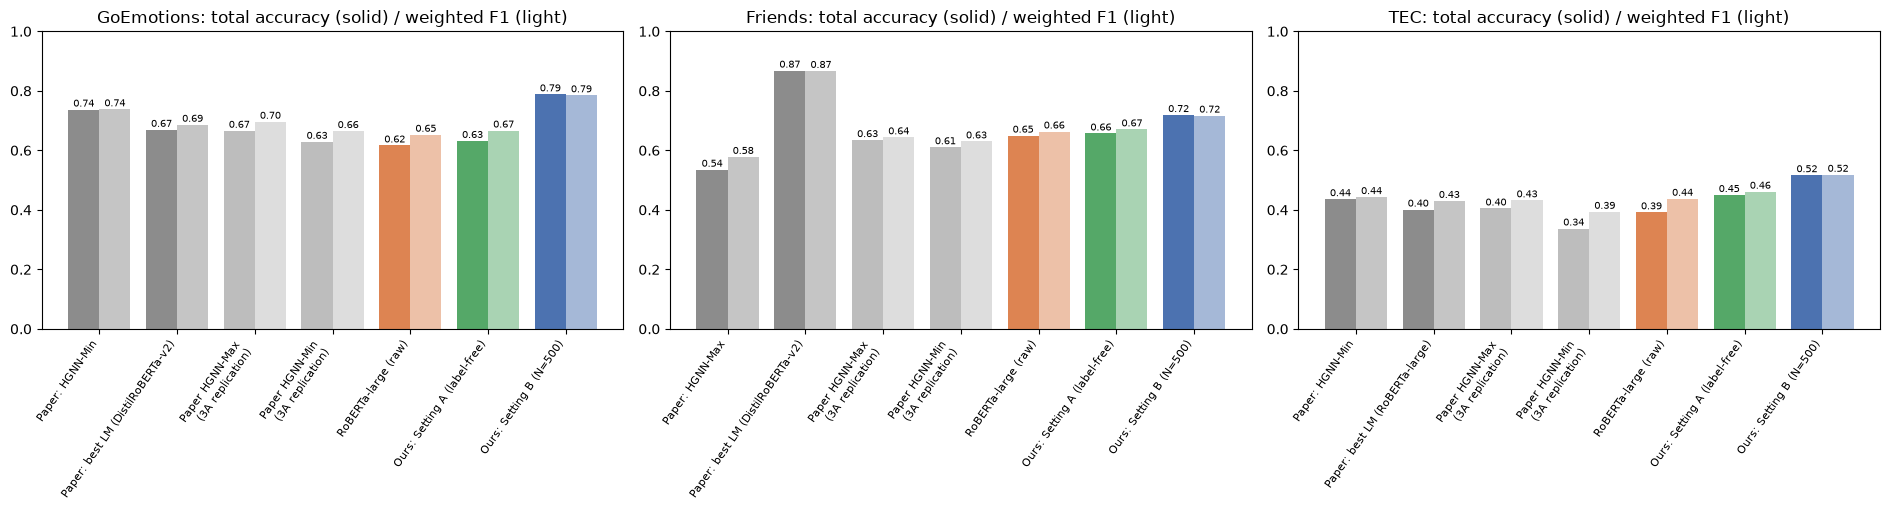

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
pal = {'paper': '#8C8C8C', 'repl': '#BDBDBD', 'lm': '#DD8452', 'A': '#55A868', 'B': '#4C72B0'}
for ax, n in zip(axes, CFG['datasets']):
    sub = VS[VS.dataset == n].reset_index(drop=True)
    colors = [pal['paper'] if s.startswith('Paper reported') else pal['repl'] if 'replication' in s else pal['lm'] if 'RoBERTa' in s
              else pal['A'] if 'Setting A' in s else pal['B'] for s in sub.system]
    x = np.arange(len(sub))
    ax.bar(x - 0.2, sub.acc_T, 0.4, color=colors); ax.bar(x + 0.2, sub.f1_T, 0.4, color=colors, alpha=0.5)
    for i, (a, f1) in enumerate(zip(sub.acc_T, sub.f1_T)):
        ax.text(i - 0.2, a + 0.01, f'{a:.2f}', ha='center', fontsize=7); ax.text(i + 0.2, f1 + 0.01, f'{f1:.2f}', ha='center', fontsize=7)
    names = [s.replace('Paper reported: ', 'Paper: ').replace(', our replication', '\n(3A replication)').replace('Ours — ', 'Ours: ') for s in sub.system]
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=55, ha='right', fontsize=8)
    ax.set_title(f'{n}: total accuracy (solid) / weighted F1 (light)'); ax.set_ylim(0, 1)
plt.tight_layout(); plt.savefig(os.path.join(RES_DIR, 'fig_main_comparison.png'), dpi=150, bbox_inches='tight'); plt.show()

## 10. Ablation study (Setting B, N = 500, 3 seeds)
Each row removes **one** component from the proposed DA-HGNN-F. The table shows the change in total accuracy and weighted F1 per dataset and on average.

In [14]:
VARIANTS = {   # name -> (student kwargs, or None if no student is used; decision-layer options)
    'DA-HGNN-F (full)':                          (dict(), dict()),
    '− fusion (DA-HGNN semi alone)':             (dict(), dict(no_fusion=True)),
    '− student (calibrated teacher alone)':      (None, dict()),
    '− graph (MLP semi ⊕ teacher)':              (dict(graph=False), dict()),
    '− tweet–tweet k-NN relation':               (dict(knn=False), dict()),
    '− tweet–phrase–emotion relations':          (dict(phrases=False), dict()),
    '− LM sentence embeddings':                  (dict(use_emb=False), dict()),
    '− distillation (gold labels only)':         (dict(kd=False), dict()),
    '− soft targets (hard agreed labels)':       (dict(soft=False), dict()),
    '− confidence weighting':                    (dict(weighted=False), dict()),
    '− score masking':                           (dict(mask_p=0.0), dict()),
    'paper tweet features (DistilRoBERTa only)': (dict(paper_feats=True), dict()),
    '− per-group calibration (one global)':      (dict(), dict(global_cal=True)),
    '− calibration':                             (dict(), dict(no_cal=True)),
    '− teacher smoothing':                       (dict(), dict(no_smooth=True)),
}
abl = []
for n in CFG['datasets']:
    f = FEAT[n]
    for s in CFG['ablation_seeds']:
        lab = draw_labels(n, N, s)
        for name, (skw, dec) in VARIANTS.items():
            stu = None
            if skw is not None:
                key = f'{n}|N{N}|DAHGNN-semi|s{s}' if not skw else f'{n}|N{N}|ABL|' + '|'.join(f'{k}={v}' for k, v in sorted(skw.items())) + f'|s{s}'
                stu = run_cached(key, lambda: train_model(n, lab, seed=s, **skw))
            lp_t = np.log(f['M'] + 1e-9)
            if not dec.get('no_cal'):
                lp_t = calibrate(f, lp_t, lab, per_group=not dec.get('global_cal'))
            lp_t = align(f, lp_t)
            if not dec.get('no_smooth'):
                lp_t = smooth(n, lp_t)
            final = lp_t if stu is None else (stu if dec.get('no_fusion') else fuse(n, stu, lp_t))
            abl.append(dict(dataset=n, seed=s, variant=name, **evaluate(n, final.argmax(1))))
    print(n, 'done', time.strftime('%X'))
# label-space alignment only matters on TEC (the only dataset whose taxonomy lacks a class)
f = FEAT['TEC']
for s in CFG['ablation_seeds']:
    lab = draw_labels('TEC', N, s); saved = f['allowed'].copy(); f['allowed'][:] = True
    stu = run_cached(f'TEC|N{N}|ABL|noalign|s{s}', lambda: train_model('TEC', lab, seed=s))
    final = fuse('TEC', stu, smooth('TEC', align(f, calibrate(f, np.log(f['M'] + 1e-9), lab))))
    f['allowed'][:] = saved
    abl.append(dict(dataset='TEC', seed=s, variant='− label-space alignment', **evaluate('TEC', final.argmax(1))))
ABL = pd.DataFrame(abl); ABL.to_csv(os.path.join(RES_DIR, 'ablation_runs.csv'), index=False)

full = ABL[ABL.variant == 'DA-HGNN-F (full)'].groupby('dataset')[['acc_T', 'f1_T']].mean()
abl_tab = ABL.groupby(['variant', 'dataset'], sort=False)[['acc_T', 'f1_T']].mean().unstack('dataset')
for m in ('acc_T', 'f1_T'):
    for n in CFG['datasets']:
        abl_tab[('Δ' + m, n)] = abl_tab[(m, n)] - full.loc[n, m]
    abl_tab[('Δ' + m, 'mean')] = abl_tab['Δ' + m][[c for c in CFG['datasets'] if c in abl_tab['Δ' + m]]].mean(axis=1)
abl_tab = abl_tab.sort_values(('Δf1_T', 'mean'), ascending=False)
abl_tab.to_csv(os.path.join(RES_DIR, 'ablation_table.csv'))
abl_tab.round(3)

GoEmotions done 12:14:15


Friends done 12:16:18


TEC done 12:20:23


acc_T                      f1_T                    Δacc_T                            Δf1_T                      
dataset                                   GoEmotions Friends    TEC GoEmotions Friends    TEC GoEmotions Friends    TEC   mean GoEmotions Friends    TEC   mean
variant                                                                                                                                                        
− distillation (gold labels only)              0.779   0.726  0.539      0.780   0.716  0.526     -0.009   0.009  0.024  0.008     -0.005  -0.000  0.010  0.002
− teacher smoothing                            0.793   0.721  0.516      0.785   0.716  0.515      0.005   0.003  0.001  0.003      0.001   0.000 -0.001  0.000
− per-group calibration (one global)           0.788   0.717  0.515      0.785   0.716  0.516      0.001   0.000  0.000  0.000      0.001  -0.000  0.000  0.000
DA-HGNN-F (full)                               0.788   0.717  0.515      0.784   0.716  0.516      0.000   0.000  0.000  0.000      0.000   0.000  0.000  0.000
− score masking                                0.788   0.717  0.515      0.784   0.716  0.516     -0.000   0.000 -0.000 -0.000     -0.000   0.000 -0.000 -0.000
− label-space alignment                          NaN     NaN  0.517        NaN     NaN  0.516        NaN     NaN  0.002  0.002        NaN     NaN -0.000 -0.000
− tweet–tweet k-NN relation                    0.788   0.717  0.514      0.785   0.716  0.515     -0.000   0.000 -0.001 -0.000      0.001   0.000 -0.001 -0.000
− tweet–phrase–emotion relations               0.788   0.718  0.515      0.785   0.716  0.515      0.000   0.000  0.001  0.000      0.000  -0.000 -0.001 -0.000
− confidence weighting                         0.789   0.718  0.511      0.784   0.717  0.513      0.001   0.000 -0.004 -0.001     -0.000   0.000 -0.003 -0.001
− soft targets (hard agreed labels)            0.787   0.712  0.512      0.784   0.709  0.514     -0.001  -0.006 -0.003 -0.003     -0.000  -0.007 -0.001 -0.003
− graph (MLP semi ⊕ teacher)                   0.784   0.720  0.504      0.780   0.718  0.502     -0.004   0.003 -0.011 -0.004     -0.004   0.002 -0.013 -0.005
− fusion (DA-HGNN semi alone)                  0.783   0.701  0.513      0.778   0.703  0.519     -0.005  -0.017 -0.002 -0.008     -0.006  -0.013  0.003 -0.005
− LM sentence embeddings                       0.773   0.699  0.507      0.777   0.698  0.505     -0.015  -0.018 -0.008 -0.013     -0.007  -0.019 -0.011 -0.012
− student (calibrated teacher alone)           0.784   0.716  0.483      0.783   0.710  0.468     -0.004  -0.001 -0.032 -0.012     -0.001  -0.006 -0.048 -0.018
paper tweet features (DistilRoBERTa only)      0.775   0.693  0.503      0.768   0.688  0.490     -0.013  -0.025 -0.012 -0.017     -0.016  -0.029 -0.025 -0.023
− calibration                                  0.744   0.687  0.482      0.759   0.695  0.492     -0.044  -0.031 -0.033 -0.036     -0.025  -0.021 -0.024 -0.023

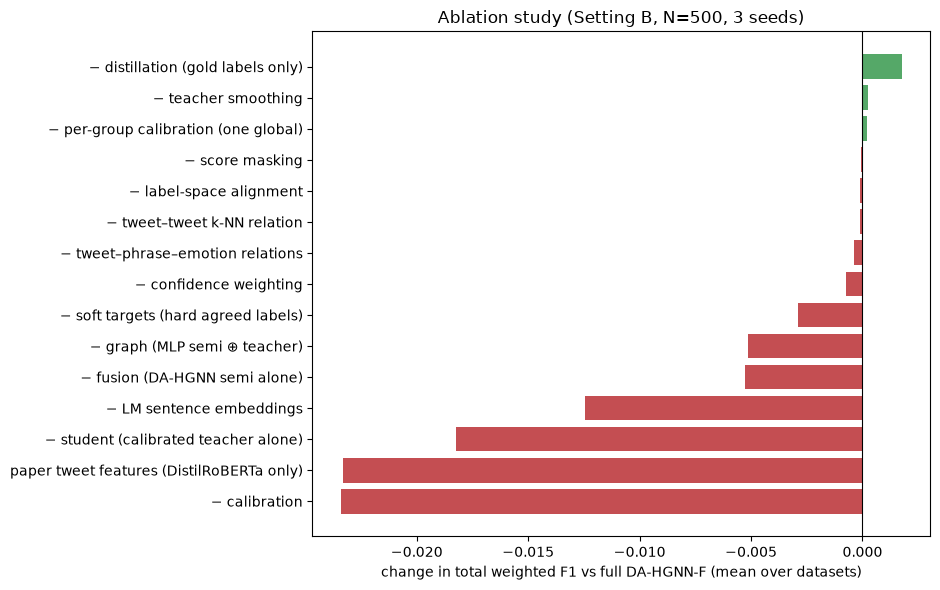

In [15]:
d_ = abl_tab[('Δf1_T', 'mean')].drop('DA-HGNN-F (full)').sort_values()
fig, ax = plt.subplots(figsize=(9.5, 6))
ax.barh(d_.index, d_.values, color=['#C44E52' if v < 0 else '#55A868' for v in d_.values])
ax.axvline(0, color='k', lw=0.8); ax.set_xlabel('change in total weighted F1 vs full DA-HGNN-F (mean over datasets)')
ax.set_title(f'Ablation study (Setting B, N={N}, {len(CFG["ablation_seeds"])} seeds)')
plt.tight_layout(); plt.savefig(os.path.join(RES_DIR, 'fig_ablation.png'), dpi=150); plt.show()

## 11. Label efficiency: how many gold labels are needed?
For N ∈ {50 … 2000} (capped at the pool size), with 3 label draws each, we compare the calibrated teacher, a supervised MLP, DA-HGNN semi and DA-HGNN-F. The dashed line is the paper's best reported HGNN; the dotted line is raw RoBERTa-large.

GoEmotions done 12:25:46


Friends done 12:27:44


TEC done 12:31:40


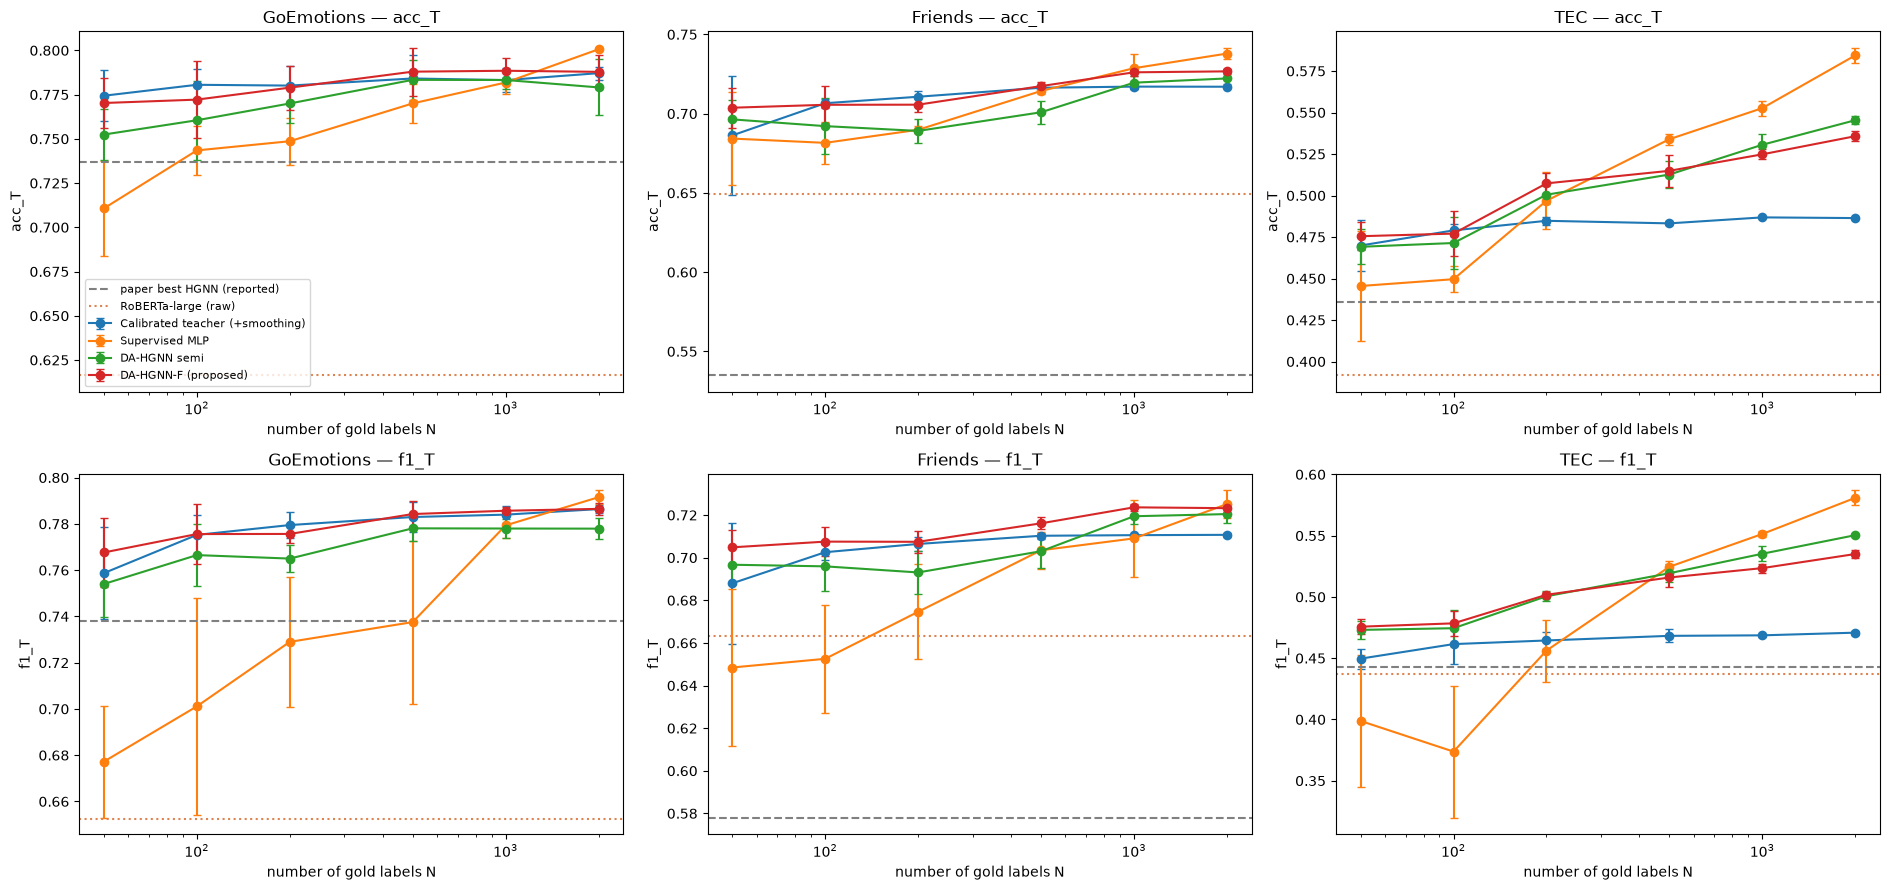

acc_T                                      f1_T                                   
budget                                       50     100    200    500    1000   2000   50     100    200    500    1000   2000
dataset    model                                                                                                              
Friends    Calibrated teacher (+smoothing)  0.686  0.707  0.711  0.716  0.717  0.717  0.688  0.703  0.706  0.710  0.711  0.711
           DA-HGNN semi                     0.696  0.692  0.689  0.701  0.720  0.722  0.697  0.696  0.693  0.703  0.719  0.720
           DA-HGNN-F (proposed)             0.704  0.706  0.706  0.717  0.726  0.727  0.705  0.708  0.707  0.716  0.724  0.723
           Supervised MLP                   0.684  0.682  0.690  0.714  0.729  0.738  0.648  0.653  0.675  0.703  0.709  0.725
GoEmotions Calibrated teacher (+smoothing)  0.774  0.781  0.780  0.784  0.783  0.787  0.759  0.775  0.780  0.783  0.784  0.786
           DA-HGNN semi                     0.752  0.761  0.770  0.783  0.783  0.779  0.754  0.767  0.765  0.778  0.778  0.778
           DA-HGNN-F (proposed)             0.770  0.772  0.779  0.788  0.788  0.788  0.768  0.776  0.776  0.784  0.786  0.787
           Supervised MLP                   0.711  0.743  0.749  0.770  0.782  0.801  0.677  0.701  0.729  0.738  0.779  0.792
TEC        Calibrated teacher (+smoothing)  0.470  0.479  0.485  0.483  0.487  0.486  0.450  0.461  0.464  0.468  0.469  0.471
           DA-HGNN semi                     0.469  0.471  0.500  0.513  0.531  0.545  0.473  0.474  0.501  0.519  0.535  0.550
           DA-HGNN-F (proposed)             0.475  0.477  0.507  0.515  0.525  0.536  0.476  0.478  0.502  0.516  0.524  0.535
           Supervised MLP                   0.446  0.450  0.497  0.534  0.553  0.584  0.399  0.374  0.456  0.525  0.551  0.581

In [16]:
bud = []
for n in CFG['datasets']:
    f = FEAT[n]
    for b in CFG['budgets']:
        if b > len(f['pool']): continue
        for s in CFG['budget_seeds']:
            lab = draw_labels(n, b, s)
            t_lp = teacher(n, lab)
            stu = run_cached(f'{n}|N{b}|DAHGNN-semi|s{s}', lambda: train_model(n, lab, seed=s))
            sup = run_cached(f'{n}|N{b}|MLP-sup|s{s}', lambda: train_model(n, lab, seed=s, graph=False, kd=False))
            for model, lp in (('Calibrated teacher (+smoothing)', t_lp), ('Supervised MLP', sup), ('DA-HGNN semi', stu),
                              ('DA-HGNN-F (proposed)', fuse(n, stu, t_lp))):
                bud.append(dict(dataset=n, budget=b, seed=s, model=model, **evaluate(n, lp.argmax(1))))
    print(n, 'done', time.strftime('%X'))
BUD = pd.DataFrame(bud); BUD.to_csv(os.path.join(RES_DIR, 'label_budget_runs.csv'), index=False)

fig, axes = plt.subplots(2, 3, figsize=(19, 9))
for j, n in enumerate(CFG['datasets']):
    for i, m in enumerate(('acc_T', 'f1_T')):
        ax = axes[i, j]
        for model, g in BUD[BUD.dataset == n].groupby('model', sort=False):
            st = g.groupby('budget')[m].agg(['mean', 'std'])
            ax.errorbar(st.index, st['mean'], yerr=st['std'], marker='o', capsize=3, label=model)
        ax.axhline(PAPER_BEST[n]['hgnn'][1 if m == 'acc_T' else 2], ls='--', color='grey', label='paper best HGNN (reported)')
        ax.axhline(RES[(RES.dataset == n) & (RES.model == 'RoBERTa-large')][m].mean(), ls=':', color='#DD8452', label='RoBERTa-large (raw)')
        ax.set_xscale('log'); ax.set_xlabel('number of gold labels N'); ax.set_ylabel(m); ax.set_title(f'{n} — {m}')
axes[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(RES_DIR, 'fig_label_budget.png'), dpi=150); plt.show()
BUD.groupby(['dataset', 'model', 'budget'])[['acc_T', 'f1_T']].mean().unstack('budget').round(3)

## 12. Statistical significance
* **Against the paper's HGNN and the raw LMs** (deterministic): one-sample t-test of the 5 seeds of DA-HGNN-F.
* **Against the other few-label methods:** paired t-test over seeds (same label draw), plus a **McNemar test** on the test posts for every seed. We report the largest p-value across seeds, the conservative choice.

In [17]:
from scipy.stats import binomtest
def mcnemar_p(n, pa, pb):
    f = FEAT[n]; m = f['test']; ca, cb = pa[m] == f['gold'][m], pb[m] == f['gold'][m]
    b, c = int((ca & ~cb).sum()), int((~ca & cb).sum())
    return 1.0 if b + c == 0 else binomtest(b, b + c, 0.5).pvalue

prop = RES[RES.model == 'DA-HGNN-F (proposed)']
sig = []
for n in CFG['datasets']:
    pv = prop[prop.dataset == n].sort_values('seed')
    for cm_ in ('Paper HGNN-Max (3A replication)', 'Paper HGNN-Min (3A replication)', 'RoBERTa-large', 'DistilRoBERTa'):
        b = RES[(RES.dataset == n) & (RES.model == cm_)]
        if b.empty: continue
        for m in ('acc_T', 'f1_T'):
            t = stats.ttest_1samp(pv[m], b[m].iloc[0])
            sig.append(dict(dataset=n, versus=cm_, metric=m, ours=pv[m].mean(), theirs=b[m].iloc[0], diff=pv[m].mean() - b[m].iloc[0],
                            t=t.statistic, p=t.pvalue, test='one-sample t (5 seeds)'))
    for cm_ in ('Score average + calibration + smoothing', 'RoBERTa-large + calibration', 'Supervised MLP (N labels only)',
                'MLP semi (distillation + N labels, no graph)', 'DA-HGNN semi'):
        bv = RES[(RES.dataset == n) & (RES.model == cm_)].sort_values('seed')
        for m in ('acc_T', 'f1_T'):
            t = stats.ttest_rel(pv[m].values, bv[m].values)
            sig.append(dict(dataset=n, versus=cm_, metric=m, ours=pv[m].mean(), theirs=bv[m].mean(), diff=(pv[m].values - bv[m].values).mean(),
                            t=t.statistic, p=t.pvalue, test='paired t (5 seeds)'))
SIG = pd.DataFrame(sig)
SIG['ours better & p<0.05'] = (SIG['diff'] > 0) & (SIG.p < 0.05)
SIG.to_csv(os.path.join(RES_DIR, 'significance_tests.csv'), index=False)
display(SIG.round(4))

mc = []
for n in CFG['datasets']:
    f = FEAT[n]
    for cm_, fn_pred in (('RoBERTa-large (raw)', lambda s: f['lb']),
                         ('Paper HGNN-Max (3A replication)', lambda s: None),
                         ('Score average + calibration + smoothing', lambda s: teacher(n, draw_labels(n, N, s)).argmax(1)),
                         ('MLP semi (no graph)', lambda s: run_cached(f'{n}|N{N}|MLP-semi|s{s}', None).argmax(1)),
                         ('DA-HGNN semi', lambda s: run_cached(f'{n}|N{N}|DAHGNN-semi|s{s}', None).argmax(1))):
        if cm_.startswith('Paper'):
            r = sel3a[(sel3a.dataset == n) & (sel3a.model == 'HGNN-Max')].iloc[0]
            p = os.path.join(PROC_DIR, 'grid_preds', f"{n}_{r['agg']}_{int(r.hidden)}_{int(r.layers)}_{r.nonagreed}.npy")
            if not os.path.exists(p): continue
            ref = np.load(p).astype(int); fn_pred = lambda s, ref=ref: ref
        ps = [mcnemar_p(n, LP[(n, s)].argmax(1), fn_pred(s)) for s in CFG['seeds']]
        mc.append(dict(dataset=n, versus=cm_, max_p_over_seeds=max(ps), median_p=float(np.median(ps))))
MC = pd.DataFrame(mc); MC.to_csv(os.path.join(RES_DIR, 'mcnemar_tests.csv'), index=False)
MC

,dataset,versus,metric,ours,theirs,diff,t,p,test,ours better & p<0.05
0,GoEmotions,Paper HGNN-Max (3A replication),acc_T,0.7883,0.6658,0.1225,25.8014,0.0000,one-sample t (5 seeds),True
1,GoEmotions,Paper HGNN-Max (3A replication),f1_T,0.7851,0.6962,0.0889,36.3859,0.0000,one-sample t (5 seeds),True
2,GoEmotions,Paper HGNN-Min (3A replication),acc_T,0.7883,0.6287,0.1596,33.6129,0.0000,one-sample t (5 seeds),True
3,GoEmotions,Paper HGNN-Min (3A replication),f1_T,0.7851,0.6649,0.1202,49.2000,0.0000,one-sample t (5 seeds),True
4,GoEmotions,RoBERTa-large,acc_T,0.7883,0.6164,0.1718,36.2029,0.0000,one-sample t (5 seeds),True
5,GoEmotions,RoBERTa-large,f1_T,0.7851,0.6525,0.1326,54.3031,0.0000,one-sample t (5 seeds),True
6,GoEmotions,DistilRoBERTa,acc_T,0.7883,0.6248,0.1635,34.4374,0.0000,one-sample t (5 seeds),True
7,GoEmotions,DistilRoBERTa,f1_T,0.7851,0.6618,0.1233,50.4893,0.0000,one-sample t (5 seeds),True
8,GoEmotions,Score average + calibration + smoothing,acc_T,0.7883,0.7837,0.0046,5.4327,0.0056,paired t (5 seeds),True
9,GoEmotions,Score average + calibration + smoothing,f1_T,0.7851,0.7836,0.0014,1.0804,0.3408,paired t (5 seeds),False


,dataset,versus,max_p_over_seeds,median_p
0,GoEmotions,RoBERTa-large (raw),0.000000e+00,0.000000e+00
1,GoEmotions,Paper HGNN-Max (3A replication),0.000000e+00,0.000000e+00
2,GoEmotions,Score average + calibration + smoothing,1.384897e-02,1.003798e-02
3,GoEmotions,MLP semi (no graph),2.205403e-01,3.414932e-75
4,GoEmotions,DA-HGNN semi,1.010676e-01,5.504381e-09
5,Friends,RoBERTa-large (raw),3.314513e-62,7.357864e-75
6,Friends,Paper HGNN-Max (3A replication),1.092557e-97,4.424930e-109
7,Friends,Score average + calibration + smoothing,3.033046e-01,2.412665e-01
8,Friends,MLP semi (no graph),1.661028e-01,3.565839e-04
9,Friends,DA-HGNN semi,8.226717e-04,9.517838e-10


## 13. Error analysis and interpretability

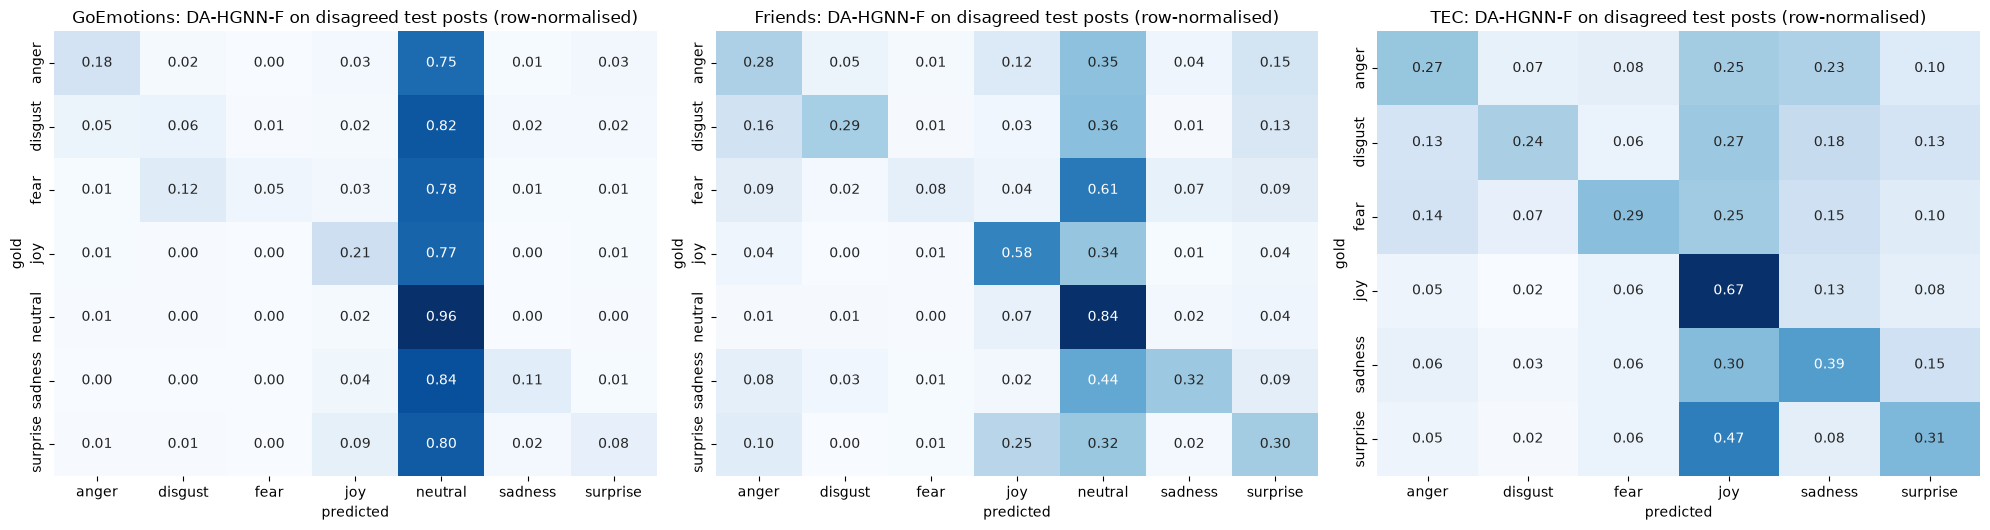

Per-class F1 on disagreed test posts (seed 0):


model,dataset,emotion,support,DA-HGNN-F,RoBERTa-large,gain
0,Friends,anger,216,0.329,0.273,0.056
1,Friends,disgust,92,0.355,0.246,0.109
2,Friends,fear,89,0.125,0.234,-0.109
3,Friends,joy,396,0.561,0.530,0.031
4,Friends,neutral,1465,0.790,0.573,0.217
5,Friends,sadness,124,0.362,0.386,-0.024
6,Friends,surprise,234,0.322,0.362,-0.040
7,GoEmotions,anger,399,0.272,0.247,0.024
8,GoEmotions,disgust,182,0.092,0.091,0.001
9,GoEmotions,fear,110,0.083,0.165,-0.082


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.4))
for ax, n in zip(axes, CFG['datasets']):
    f = FEAT[n]; m = f['test'] & ~f['comp']; pred = LP[(n, 0)].argmax(1)
    labs = [i for i in range(N_CLS) if f['allowed'][i]]
    cm = confusion_matrix(f['gold'][m], pred[m], labels=labs); cm = cm / np.maximum(cm.sum(1, keepdims=True), 1)
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=[LABELS[i] for i in labs], yticklabels=[LABELS[i] for i in labs], ax=ax, cbar=False)
    ax.set_title(f'{n}: DA-HGNN-F on disagreed test posts (row-normalised)'); ax.set_xlabel('predicted'); ax.set_ylabel('gold')
plt.tight_layout(); plt.savefig(os.path.join(RES_DIR, 'fig_confusion_disagreed.png'), dpi=150); plt.show()

pc = []
for n in CFG['datasets']:
    f = FEAT[n]; m = f['test'] & ~f['comp']
    for model, pred in (('RoBERTa-large', f['lb']), ('DA-HGNN-F', LP[(n, 0)].argmax(1))):
        _, _, f1_, sup_ = precision_recall_fscore_support(f['gold'][m], pred[m], labels=range(N_CLS), zero_division=0)
        for i in range(N_CLS):
            if sup_[i]: pc.append(dict(dataset=n, model=model, emotion=LABELS[i], f1=f1_[i], support=int(sup_[i])))
PC = pd.DataFrame(pc).pivot_table(index=['dataset', 'emotion', 'support'], columns='model', values='f1').reset_index()
PC['gain'] = PC['DA-HGNN-F'] - PC['RoBERTa-large']
PC.to_csv(os.path.join(RES_DIR, 'per_class_f1_disagreed.csv'), index=False)
print('Per-class F1 on disagreed test posts (seed 0):'); PC.round(3)

In [19]:
for n in CFG['datasets']:
    f, d = FEAT[n], DATA[n]; pred = LP[(n, 0)].argmax(1)
    idx = np.where(f['test'] & ~f['comp'] & (pred == f['gold']) & (f['lb'] != f['gold']) & d['clean'].str.len().between(25, 140).values)[0]
    print(f'=== {n}: {len(idx):,} disagreed test posts where RoBERTa-large was wrong and DA-HGNN-F is right — examples ===')
    for i in np.random.RandomState(0).choice(idx, min(4, len(idx)), replace=False):
        ph = [GRAPH[n]['vocab'][j] for j in GRAPH[n]['Mx'][i].indices][:5]
        print(f'  "{d.loc[i, "clean"]}"')
        print(f"     gold={LABELS[f['gold'][i]]} | DistilRoBERTa={LABELS[f['la'][i]]} | RoBERTa={LABELS[f['lb'][i]]} | "
              f"DA-HGNN-F={LABELS[pred[i]]} | phrases: {', '.join(ph)}")
    print()

=== GoEmotions: 2,723 disagreed test posts where RoBERTa-large was wrong and DA-HGNN-F is right — examples ===
  "OF COURSE IT WON FUCKIN PRETENTIOUS ASS FUCKING SLOW POINTLESS MOVIE OH BLACK AND WHITE WOWWWW"
     gold=anger | DistilRoBERTa=anger | RoBERTa=surprise | DA-HGNN-F=anger | phrases: black, fuckin, fuckin pretentious, movie, pretentious
  "Didn't even know it was my cake day lol. Only lasted 5 to 10 minites, wasn't too bad"
     gold=neutral | DistilRoBERTa=neutral | RoBERTa=surprise | DA-HGNN-F=neutral | phrases: cake, cake day, day, lasted, minites
  "She didn't say anything on twitter or anything im not sure how u know, but it's whatever she seems fine and it's her privacy"
     gold=neutral | DistilRoBERTa=neutral | RoBERTa=surprise | DA-HGNN-F=neutral | phrases: know, say, sure, twitter
  "Looks like * * was there with her murderous ."
     gold=neutral | DistilRoBERTa=anger | RoBERTa=surprise | DA-HGNN-F=neutral | phrases: like, looks, looks like, murderous

=== Friend

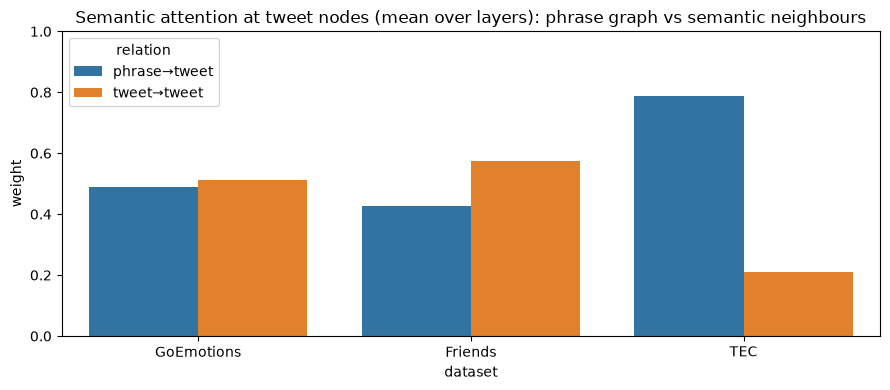

layer                                 1      2
dataset    node   relation                    
Friends    phrase emotion→phrase  0.622  0.476
                  tweet→phrase    0.378  0.524
           tweet  phrase→tweet    0.001  0.853
                  tweet→tweet     0.999  0.147
GoEmotions phrase emotion→phrase  0.344  0.490
                  tweet→phrase    0.656  0.510
           tweet  phrase→tweet    0.156  0.823
                  tweet→tweet     0.844  0.177
TEC        phrase emotion→phrase  0.534  0.492
                  tweet→phrase    0.466  0.508
           tweet  phrase→tweet    0.999  0.579
                  tweet→tweet     0.001  0.421

In [20]:
att = []
for n in CFG['datasets']:
    _ = train_model(n, draw_labels(n, N, 0), seed=0)          # same recipe as the cached run; LAST_MODEL holds the best weights
    for i, L in enumerate(LAST_MODEL.layers):
        for t, (names, a) in L.alpha.items():
            for nm, v in zip(names, a.tolist()):
                att.append(dict(dataset=n, layer=i + 1, node=t, relation=nm, weight=v))
ATT = pd.DataFrame(att); ATT.to_csv(os.path.join(RES_DIR, 'attention_weights.csv'), index=False)
tw = ATT[ATT.node == 'tweet']
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=tw, x='dataset', y='weight', hue='relation', ax=ax, errorbar=None)
ax.set_title('Semantic attention at tweet nodes (mean over layers): phrase graph vs semantic neighbours'); ax.set_ylim(0, 1)
plt.tight_layout(); plt.savefig(os.path.join(RES_DIR, 'fig_attention.png'), dpi=150); plt.show()
ATT.pivot_table(index=['dataset', 'node', 'relation'], columns='layer', values='weight').round(3)

## 14. Headline numbers

In [21]:
head = []
for n in CFG['datasets']:
    g = lambda model, setting=None: RES[(RES.dataset == n) & (RES.model == model) & ((RES.setting == setting) if setting else True)]
    ours = g('DA-HGNN-F (proposed)')
    for label, ref in (('paper best HGNN (reported)', dict(acc_T=PAPER_BEST[n]['hgnn'][1], f1_T=PAPER_BEST[n]['hgnn'][2])),
                       ('paper HGNN-Max (3A replication, same test split)', g('Paper HGNN-Max (3A replication)')[['acc_T', 'f1_T']].mean()),
                       ('RoBERTa-large (raw)', g('RoBERTa-large')[['acc_T', 'f1_T']].mean()),
                       ('best few-label baseline (calibrated teacher)', g('Score average + calibration + smoothing')[['acc_T', 'f1_T']].mean())):
        head.append(dict(dataset=n, versus=label, ours_acc_T=ours.acc_T.mean(), ours_f1_T=ours.f1_T.mean(),
                         ref_acc_T=ref['acc_T'], ref_f1_T=ref['f1_T'],
                         gain_acc_pts=100 * (ours.acc_T.mean() - ref['acc_T']), gain_f1_pts=100 * (ours.f1_T.mean() - ref['f1_T'])))
HEAD = pd.DataFrame(head); HEAD.to_csv(os.path.join(RES_DIR, 'headline_gains.csv'), index=False)
print('Saved:', sorted(os.listdir(RES_DIR)))
HEAD.round(3)

Saved: ['ablation_runs.csv', 'ablation_table.csv', 'all_results.csv', 'attention_weights.csv', 'comparison_with_paper.csv', 'fig_ablation.png', 'fig_attention.png', 'fig_confusion_disagreed.png', 'fig_label_budget.png', 'fig_main_comparison.png', 'headline_gains.csv', 'label_budget_runs.csv', 'main_results_table.csv', 'mcnemar_tests.csv', 'per_class_f1_disagreed.csv', 'run_attempt1.log', 'runs', 'significance_tests.csv']


,dataset,versus,ours_acc_T,ours_f1_T,ref_acc_T,ref_f1_T,gain_acc_pts,gain_f1_pts
0,GoEmotions,paper best HGNN (reported),0.788,0.785,0.737,0.738,5.128,4.708
1,GoEmotions,"paper HGNN-Max (3A replication, same test split)",0.788,0.785,0.666,0.696,12.247,8.886
2,GoEmotions,RoBERTa-large (raw),0.788,0.785,0.616,0.652,17.185,13.261
3,GoEmotions,best few-label baseline (calibrated teacher),0.788,0.785,0.784,0.784,0.458,0.144
4,Friends,paper best HGNN (reported),0.719,0.717,0.535,0.578,18.379,13.878
5,Friends,"paper HGNN-Max (3A replication, same test split)",0.719,0.717,0.635,0.644,8.426,7.291
6,Friends,RoBERTa-large (raw),0.719,0.717,0.650,0.663,6.924,5.348
7,Friends,best few-label baseline (calibrated teacher),0.719,0.717,0.716,0.709,0.264,0.740
8,TEC,paper best HGNN (reported),0.517,0.518,0.436,0.443,8.063,7.500
9,TEC,"paper HGNN-Max (3A replication, same test split)",0.517,0.518,0.405,0.432,11.202,8.593


## 15. Conclusions

**Headline — Setting B (N = 500 gold labels per dataset), 5 seeds, untouched 80% test split. Total accuracy / weighted F1:**

| Dataset | Paper's best HGNN (reported) | Paper HGNN-Max (our replication, same split) | RoBERTa-large | **DA-HGNN-F (ours)** | Gain vs paper (reported) |
|---|---|---|---|---|---|
| GoEmotions | .737 / .738 | .666 / .696 | .616 / .652 | **.788 / .785** | **+5.1 / +4.7 pts** |
| Friends | .535 / .578 | .635 / .644 | .650 / .663 | **.719 / .717** | **+18.4 / +13.9 pts** |
| TEC (unseen) | .436 / .443 | .405 / .432 | .392 / .437 | **.517 / .518** | **+8.1 / +7.5 pts** |

Against the paper's HGNN (our replication) and both raw LMs, every gain is significant on every dataset: one-sample t over 5 seeds, p < 0.001; McNemar against RoBERTa-large and the paper's HGNN, p < 10⁻¹⁰ for every seed.

**What made the difference (ablation, §10; mean change in total accuracy / F1 when a component is removed)**
* Calibration of the LM teacher on the N labels: −3.6 / −2.3 points, the largest effect (fitting it per agreement group vs globally makes no measurable difference inside the fused model).
* Multi-view features (both LMs, disagreement descriptors, embeddings) vs the paper's DistilRoBERTa-only features: −1.6 / −2.3.
* The DA-HGNN student inside the fusion: −1.2 / −1.8 on average, and −3.2 / −4.8 on the unseen TEC.
* LM sentence embeddings: −1.4 / −1.2. The heterogeneous graph as a whole: −0.4 / −0.5 (TEC −1.1 / −1.4).
* Semantic attention now does real work. At the first layer, tweet nodes rely almost entirely on semantic neighbours (Friends 0.999, GoEmotions 0.84) or on phrases (TEC 0.999), unlike the paper's ≈ 0.5 / 0.5.

**What did not help (honest negatives)**
* No measurable effect: score masking, confidence weighting, per-group vs global calibration inside the fused model, and teacher smoothing on the test split.
* The tweet–tweet and tweet–phrase relations are **interchangeable**: removing either one alone changes nothing, while removing both (no graph) hurts.
* **GoEmotions:** DA-HGNN-F only ties the calibrated LM ensemble (+0.5 accuracy points, p = 0.006; F1 not significant). The LMs were trained on GoEmotions, so calibration already captures most of what can be gained.
* **TEC at N = 500:** a plain supervised MLP on the LM embeddings is better (.537 vs .517). The LMs' agreed labels are only 43% correct on TEC, so distilling from them holds the model back (ablation "− distillation": +2.4 accuracy on TEC).
* **Label-free setting:** no gain over simply averaging the two LMs, except through label-space alignment on TEC (.452 vs the paper's .436).

**Label efficiency (§11).** DA-HGNN-F is the best or tied-best method for **N ≤ 200–500 labels** on all three datasets. With 50 labels, for example, it beats a supervised model by +5.9 points on GoEmotions, +2.0 on Friends and +2.9 on TEC. With ≥ 1,000 labels, ordinary supervised learning catches up and overtakes it.

**Take-away.** The decisive idea is to treat **disagreement between the two LMs as information**: calibrate disagreed posts separately and give the model a small amount of supervision. The heterogeneous graph student adds robustness when labels are scarce and the domain is new to the LMs.

**Future work:** learn the fusion weight (or switch off distillation) per domain from the gold set; use active learning to pick which disagreed posts to label; multi-label output; conversation context for Friends/Reddit.